<a href="https://colab.research.google.com/github/sebastianvettel1212/GrokkingDeepLearning/blob/main/05_Generalizing_Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bab 5 — Generalisasi *Gradient Descent*: Belajar Banyak Bobot Sekaligus (*Learning Multiple Weights at a Time*)

**Buku:** *Grokking Deep Learning* — Andrew W. Trask (Manning, 2019)

Bab 4 memakai **satu bobot**. Bab 5 memperluasnya ke **banyak bobot**: banyak input, banyak output, dan keduanya. Kode diambil dari repositori resmi buku, ditambah teori dan satu ilustrasi pada dataset digit (berlabel *Tambahan*).

> **Catatan:** pada notebook resmi buku, sel pertama memakai `weight_deltas` sebelum didefinisikan. Di sini ditambahkan satu baris `weight_deltas = ele_mul(delta, input)` agar kode dapat dijalankan.

---

## Daftar Isi
1. *Gradient Descent* dengan Banyak Input
2. Mengamati Beberapa Langkah Belajar
3. Membekukan Satu Bobot (*Freezing One Weight*)
4. *Gradient Descent* dengan Banyak Output
5. Banyak Input dan Banyak Output
6. Visualisasi Bobot sebagai Template *(Tambahan)*
7. Ringkasan Bab

## 1. *Gradient Descent* dengan Banyak Input

Dengan banyak input, prediksi adalah *weighted sum* sehingga **satu *delta* output** dibagikan ke **banyak bobot**:
$$\text{delta}=\text{pred}-\text{goal},\qquad \text{weight\_delta}_i=\text{input}_i\times\text{delta},\qquad w_i\leftarrow w_i-\alpha\cdot\text{weight\_delta}_i$$
Intuisinya: setiap bobot ikut "bertanggung jawab" atas error, sebesar **seberapa besar input-nya**. Satu delta, banyak *weight delta*.

In [1]:
def w_sum(a,b):
    assert(len(a) == len(b))
    output = 0

    for i in range(len(a)):
        output += (a[i] * b[i])

    return output

weights = [0.1, 0.2, -.1]

def neural_network(input,weights):
    pred = w_sum(input,weights)
    return pred

toes =  [8.5, 9.5, 9.9, 9.0]
wlrec = [0.65, 0.8, 0.8, 0.9]
nfans = [1.2, 1.3, 0.5, 1.0]

win_or_lose_binary = [1, 1, 0, 1]

true = win_or_lose_binary[0]

# Input corresponds to every entry
# for the first game of the season.

input = [toes[0],wlrec[0],nfans[0]]

pred = neural_network(input,weights)
error = (pred - true) ** 2
delta = pred - true

def ele_mul(number,vector):
    output = [0,0,0]

    assert(len(output) == len(vector))

    for i in range(len(vector)):
        output[i] = number * vector[i]

    return output

# (baris ini ditambahkan; hilang pada notebook resmi)
weight_deltas = ele_mul(delta,input)

alpha = 0.01

for i in range(len(weights)):
    weights[i] -= alpha * weight_deltas[i]

print("Weights:" + str(weights))
print("Weight Deltas:" + str(weight_deltas))

Weights:[0.1119, 0.20091, -0.09832]
Weight Deltas:[-1.189999999999999, -0.09099999999999994, -0.16799999999999987]


**Interpretasi:** `toes` (8,5) memiliki *weight delta* terbesar karena inputnya terbesar, sehingga bobot `toes` bergeser paling banyak.

---
## 2. Mengamati Beberapa Langkah Belajar

In [2]:
def neural_network(input, weights):
  out = 0
  for i in range(len(input)):
    out += (input[i] * weights[i])
  return out

def ele_mul(scalar, vector):
  out = [0,0,0]
  for i in range(len(out)):
    out[i] = vector[i] * scalar
  return out

toes =  [8.5, 9.5, 9.9, 9.0]
wlrec = [0.65, 0.8, 0.8, 0.9]
nfans = [1.2, 1.3, 0.5, 1.0]

win_or_lose_binary = [1, 1, 0, 1]
true = win_or_lose_binary[0]

alpha = 0.01
weights = [0.1, 0.2, -.1]
input = [toes[0],wlrec[0],nfans[0]]

for iter in range(3):

  pred = neural_network(input,weights)

  error = (pred - true) ** 2
  delta = pred - true

  weight_deltas=ele_mul(delta,input)

  print("Iteration:" + str(iter+1))
  print("Pred:" + str(pred))
  print("Error:" + str(error))
  print("Delta:" + str(delta))
  print("Weights:" + str(weights))
  print("Weight_Deltas:")
  print(str(weight_deltas))
  print(
  )

  for i in range(len(weights)):
    weights[i]-=alpha*weight_deltas[i]

Iteration:1
Pred:0.8600000000000001
Error:0.01959999999999997
Delta:-0.1399999999999999
Weights:[0.1, 0.2, -0.1]
Weight_Deltas:
[-1.189999999999999, -0.09099999999999994, -0.16799999999999987]

Iteration:2
Pred:0.9637574999999999
Error:0.0013135188062500048
Delta:-0.036242500000000066
Weights:[0.1119, 0.20091, -0.09832]
Weight_Deltas:
[-0.30806125000000056, -0.023557625000000044, -0.04349100000000008]

Iteration:3
Pred:0.9906177228125002
Error:8.802712522307997e-05
Delta:-0.009382277187499843
Weights:[0.11498061250000001, 0.20114557625, -0.09788509000000001]
Weight_Deltas:
[-0.07974935609374867, -0.006098480171874899, -0.011258732624999811]



**Interpretasi:** prediksi bergerak ke arah target 1 dan error mengecil di tiap iterasi. Bobot `toes` yang inputnya paling besar berubah paling cepat, sedangkan `wlrec` (input kecil) berubah lambat. Karena itu, **input dengan skala sangat berbeda** membuat belajar tidak seimbang; ini alasan *normalisasi input* penting pada praktik nyata.

---
## 3. Membekukan Satu Bobot (*Freezing One Weight*)

Bagaimana bila `weight_deltas[0] = 0` (bobot `toes` dibekukan)? Kita lihat apakah jaringan tetap bisa belajar. (*alpha* dinaikkan menjadi 0,3 agar perubahan terlihat.)

In [3]:
def neural_network(input, weights):
  out = 0
  for i in range(len(input)):
    out += (input[i] * weights[i])
  return out

def ele_mul(scalar, vector):
  out = [0,0,0]
  for i in range(len(out)):
    out[i] = vector[i] * scalar
  return out

toes =  [8.5, 9.5, 9.9, 9.0]
wlrec = [0.65, 0.8, 0.8, 0.9]
nfans = [1.2, 1.3, 0.5, 1.0]

win_or_lose_binary = [1, 1, 0, 1]
true = win_or_lose_binary[0]

alpha = 0.3
weights = [0.1, 0.2, -.1]
input = [toes[0],wlrec[0],nfans[0]]

for iter in range(3):

  pred = neural_network(input,weights)

  error = (pred - true) ** 2
  delta = pred - true

  weight_deltas=ele_mul(delta,input)
  weight_deltas[0] = 0

  print("Iteration:" + str(iter+1))
  print("Pred:" + str(pred))
  print("Error:" + str(error))
  print("Delta:" + str(delta))
  print("Weights:" + str(weights))
  print("Weight_Deltas:")
  print(str(weight_deltas))
  print(
  )

  for i in range(len(weights)):
    weights[i]-=alpha*weight_deltas[i]

Iteration:1
Pred:0.8600000000000001
Error:0.01959999999999997
Delta:-0.1399999999999999
Weights:[0.1, 0.2, -0.1]
Weight_Deltas:
[0, -0.09099999999999994, -0.16799999999999987]

Iteration:2
Pred:0.9382250000000001
Error:0.003816150624999989
Delta:-0.06177499999999991
Weights:[0.1, 0.2273, -0.04960000000000005]
Weight_Deltas:
[0, -0.040153749999999946, -0.07412999999999989]

Iteration:3
Pred:0.97274178125
Error:0.000743010489422852
Delta:-0.027258218750000007
Weights:[0.1, 0.239346125, -0.02736100000000008]
Weight_Deltas:
[0, -0.017717842187500006, -0.032709862500000006]



**Interpretasi:** meski satu bobot dibekukan, **error tetap turun** karena bobot lain mengambil alih. Pelajaran: error ditentukan **bersama oleh semua bobot**; kurva error berbentuk mangkuk dalam banyak dimensi, dan membekukan satu bobot hanya "mengiris" mangkuk itu (jaringan tetap menemukan dasar pada irisan tersebut). Jaringan berhenti belajar ketika error = 0.

---
## 4. *Gradient Descent* dengan Banyak Output

Satu input dengan beberapa output: tiap output punya *delta* sendiri, dan tiap bobot diperbarui oleh `input × delta_output` miliknya.

In [4]:
# Instead of predicting just
# whether the team won or lost,
# now we're also predicting whether
# they are happy/sad AND the
# percentage of the team that is
# hurt. We are making this
# prediction using only
# the current win/loss record.

weights = [0.3, 0.2, 0.9]

def neural_network(input, weights):
    pred = ele_mul(input,weights)
    return pred

wlrec = [0.65, 1.0, 1.0, 0.9]

hurt  = [0.1, 0.0, 0.0, 0.1]
win   = [  1,   1,   0,   1]
sad   = [0.1, 0.0, 0.1, 0.2]

input = wlrec[0]
true = [hurt[0], win[0], sad[0]]

pred = neural_network(input,weights)

error = [0, 0, 0]
delta = [0, 0, 0]

for i in range(len(true)):
    error[i] = (pred[i] - true[i]) ** 2
    delta[i] = pred[i] - true[i]

def scalar_ele_mul(number,vector):
    output = [0,0,0]

    assert(len(output) == len(vector))

    for i in range(len(vector)):
        output[i] = number * vector[i]

    return output

weight_deltas = scalar_ele_mul(input,delta)

alpha = 0.1

for i in range(len(weights)):
    weights[i] -= (weight_deltas[i] * alpha)

print("Weights:" + str(weights))
print("Weight Deltas:" + str(weight_deltas))

Weights:[0.293825, 0.25655, 0.868475]
Weight Deltas:[0.061750000000000006, -0.5655, 0.3152500000000001]


**Interpretasi:** setiap output punya error dan delta sendiri. Bobot untuk output `win` (prediksi 0,13 vs target 1) naik paling banyak karena meleset paling jauh.

---
## 5. Banyak Input dan Banyak Output

Kasus umum: bobot berupa **matriks**. *Weight delta* untuk bobot yang menghubungkan input $j$ ke output $i$ adalah $\text{delta}_i\times\text{input}_j$. Kumpulan semuanya adalah ***outer product*** vektor delta dan vektor input:
$$\text{weight\_deltas}=\text{delta}\otimes\text{input}\quad(\text{matriks }3\times3)$$

In [5]:
            #toes %win #fans
weights = [ [0.1, 0.1, -0.3],#hurt?
            [0.1, 0.2, 0.0], #win?
            [0.0, 1.3, 0.1] ]#sad?

def w_sum(a,b):
    assert(len(a) == len(b))
    output = 0

    for i in range(len(a)):
        output += (a[i] * b[i])

    return output

def vect_mat_mul(vect,matrix):
    assert(len(vect) == len(matrix))
    output = [0,0,0]
    for i in range(len(vect)):
        output[i] = w_sum(vect,matrix[i])
    return output

def neural_network(input, weights):
    pred = vect_mat_mul(input,weights)
    return pred

toes  = [8.5, 9.5, 9.9, 9.0]
wlrec = [0.65,0.8, 0.8, 0.9]
nfans = [1.2, 1.3, 0.5, 1.0]

hurt  = [0.1, 0.0, 0.0, 0.1]
win   = [  1,   1,   0,   1]
sad   = [0.1, 0.0, 0.1, 0.2]

alpha = 0.01

input = [toes[0],wlrec[0],nfans[0]]
true  = [hurt[0], win[0], sad[0]]

pred = neural_network(input,weights)

error = [0, 0, 0]
delta = [0, 0, 0]

for i in range(len(true)):
    error[i] = (pred[i] - true[i]) ** 2
    delta[i] = pred[i] - true[i]

In [6]:
import numpy as np
def outer_prod(a, b):

    # just a matrix of zeros
    out = np.zeros((len(a), len(b)))

    for i in range(len(a)):
        for j in range(len(b)):
            out[i][j] = a[i] * b[j]
    return out

weight_deltas = outer_prod(delta,input)

for i in range(len(weights)):
    for j in range(len(weights[0])):
        weights[i][j] -= alpha * weight_deltas[i][j]

In [7]:
weights

[[np.float64(0.061325), np.float64(0.0970425), np.float64(-0.30546)],
 [np.float64(0.1017), np.float64(0.20013), np.float64(0.00023999999999999887)],
 [np.float64(-0.07352500000000001),
  np.float64(1.2943775),
  np.float64(0.08962)]]

**Interpretasi:** matriks bobot 3×3 sudah diperbarui. Pembaruan terbesar terjadi pada baris `sad?` dan kolom `toes`, karena delta `sad?` paling besar (≈ 0,865) dan input `toes` paling besar (8,5), sehingga bobot itu berubah paling jauh.

---
## 6. Visualisasi Bobot sebagai Template *(Tambahan)*

> Bagian ini adalah **tambahan** (tidak ada di kode buku). Pada buku, ide ini muncul di bab berikutnya pada dataset MNIST. Di sini dipakai dataset **digit 8×8** bawaan `scikit-learn` agar bisa dijalankan tanpa unduhan.

Jaringan **satu layer** (64 input → 10 output) dilatih dengan *gradient descent* persis seperti di atas (`delta = pred - true`, `weight_deltas = outer(input, delta)`). Setiap kolom bobot dapat divisualisasikan sebagai gambar 8×8, yaitu **"template"** tiap angka yang dicari jaringan (ingat: *dot product* = kemiripan).

Akurasi latih: 0.946 | akurasi uji: 0.950


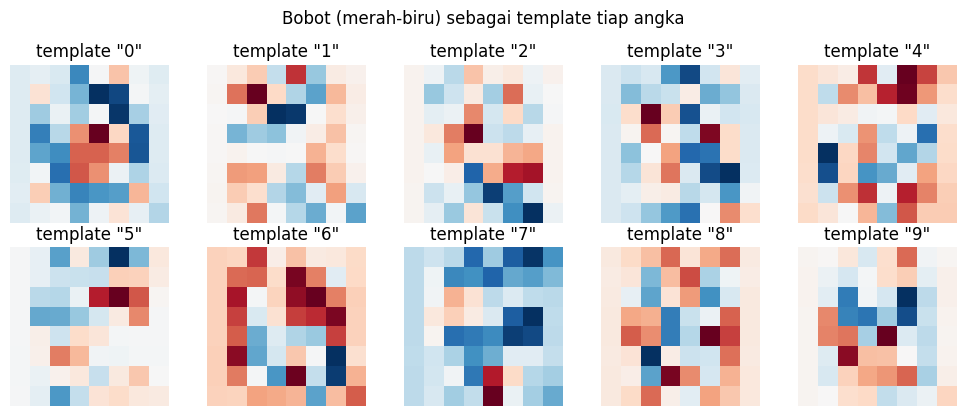

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

digits = load_digits()
X = digits.data / 16.0                       # normalisasi input ke 0..1
Y = np.eye(10)[digits.target]                # one-hot (10 output)

rng = np.random.default_rng(0)
idx = rng.permutation(len(X))
tr, te = idx[:1400], idx[1400:]

W = np.zeros((64, 10))
alpha = 0.05
for epoch in range(500):
    pred  = X[tr] @ W                        # forward propagation
    delta = pred - Y[tr]                     # delta tiap output
    W    -= alpha * (X[tr].T @ delta) / len(tr)   # weight_deltas = outer product (dirata-ratakan)

acc_tr = (np.argmax(X[tr] @ W, 1) == digits.target[tr]).mean()
acc_te = (np.argmax(X[te] @ W, 1) == digits.target[te]).mean()
print(f'Akurasi latih: {acc_tr:.3f} | akurasi uji: {acc_te:.3f}')

fig, axes = plt.subplots(2, 5, figsize=(10, 4.2))
for k, ax in enumerate(axes.ravel()):
    ax.imshow(W[:, k].reshape(8, 8), cmap='RdBu')
    ax.set_title(f'template "{k}"'); ax.axis('off')
plt.suptitle('Bobot (merah-biru) sebagai template tiap angka')
plt.tight_layout(); plt.show()

**Interpretasi:** jaringan satu layer sederhana mencapai akurasi sekitar 95% pada digit, tanpa *hidden layer*. (Dengan `alpha = 0.5` jaringan **diverge** dan akurasinya jatuh ke ≈ 10%, persis pelajaran *overcorrection* dari Bab 4: pilih *alpha* yang cukup kecil.) Gambar bobot menunjukkan **pola mirip angka** (area biru/merah menandai piksel yang menaikkan/menurunkan skor angka tersebut). Ini membuktikan intuisi bab: bobot = template, dan *dot product* mengukur kemiripan input dengan template.

---
## 7. Ringkasan Bab

- Setiap bobot diperbarui dengan `delta_output × input_bobot`; secara umum `weight_deltas = outer(delta, input)`.
- Error ditentukan **bersama** oleh semua bobot; jaringan berhenti belajar ketika error = 0.
- Input berskala besar mendominasi pembelajaran; normalisasi input membantu.
- Bobot dapat dipandang sebagai **template** yang dibandingkan dengan input lewat *dot product*.

### Rangkuman konsep
| Subbab | Konsep | Kode |
|---|---|---|
| Banyak input | Satu delta, banyak weight delta | `weight_deltas = ele_mul(delta, input)` |
| Membekukan bobot | Bobot lain mengambil alih | `weight_deltas[0] = 0` |
| Banyak output | Delta per output | `scalar_ele_mul(input, delta)` |
| Banyak input & output | *Outer product* | `outer_prod(delta, input)` |
| Template | Bobot sebagai pola | `W[:, k].reshape(8, 8)` |